In [1]:
import numpy as np
import pandas as pd
import random
import time
import optuna
import matplotlib.pyplot as plt

In [2]:
# Fonction polynomiale (modifiable)
def polynomial_function(x):
    return (x - 2)**2 + 3  # Minimum en x = 2

In [3]:
# --- GRID SEARCH ---
def grid_search(func, x_min, x_max, steps):
    res = pd.DataFrame()

    for x in np.linspace(x_min, x_max, steps):
        y = func(x)
        tmp = pd.DataFrame([{'x':x, 'y':y}])
        res = pd.concat([res,tmp], ignore_index=True)

    return res

In [4]:
# --- RANDOM SEARCH ---
def random_search(func, x_min, x_max, iterations):
    res = pd.DataFrame()

    for _ in range(iterations):
        x = random.uniform(x_min, x_max)
        y = func(x)
        tmp = pd.DataFrame([{'x':x, 'y':y}])
        res = pd.concat([res,tmp], ignore_index=True)

    return res

In [10]:
# --- OPTUNA SEARCH ---
def optuna_search(func, x_min, x_max, trials):

    def objective(trial):
        x = trial.suggest_float("x", x_min, x_max)
        return func(x)

    start = time.time()
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=trials)

    return study.trials_dataframe(), study

In [11]:
# --- COMPARAISON ---
x_min, x_max = -10, 10
steps = 30
iterations = 30
trials = 30

grid_result = grid_search(polynomial_function, x_min, x_max, steps)
random_result = random_search(polynomial_function, x_min, x_max, iterations)
optuna_result, study = optuna_search(polynomial_function, x_min, x_max, trials)
optuna_result[['x','y']] = optuna_result[['params_x','value']]

# --- AFFICHAGE COURBE ---
x_vals = np.linspace(x_min, x_max, 400)
y_vals = [polynomial_function(x) for x in x_vals]

[I 2025-05-12 16:32:13,584] A new study created in memory with name: no-name-b5bcc5cd-42ec-4746-a2b3-00b21ef08144
[I 2025-05-12 16:32:13,586] Trial 0 finished with value: 136.3638050599879 and parameters: {'x': -9.548324772883204}. Best is trial 0 with value: 136.3638050599879.
[I 2025-05-12 16:32:13,587] Trial 1 finished with value: 30.8540351278059 and parameters: {'x': -3.27769221609274}. Best is trial 1 with value: 30.8540351278059.
[I 2025-05-12 16:32:13,588] Trial 2 finished with value: 3.265911672409554 and parameters: {'x': 1.4843337587067058}. Best is trial 2 with value: 3.265911672409554.
[I 2025-05-12 16:32:13,590] Trial 3 finished with value: 14.4161310188211 and parameters: {'x': -1.37877655650993}. Best is trial 2 with value: 3.265911672409554.
[I 2025-05-12 16:32:13,590] Trial 4 finished with value: 33.84106973487614 and parameters: {'x': -3.5534736638320474}. Best is trial 2 with value: 3.265911672409554.
[I 2025-05-12 16:32:13,590] Trial 5 finished with value: 9.808304

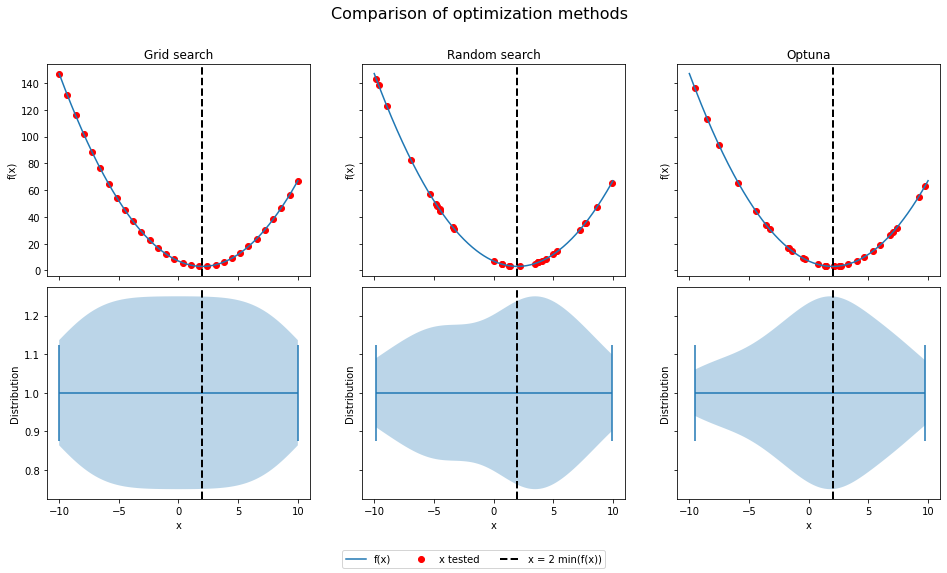

In [12]:
fig, axs = plt.subplots(2, 3, figsize=(16,8), sharex=True, sharey='row')
plt.subplots_adjust(wspace=0.2, hspace=0.05)

for ax, opt in zip(axs[0,:], ['Grid search', 'Random search', 'Optuna']):
    ax.set_title(opt)

for ax, opt in zip(axs[0,:], [grid_result, random_result, optuna_result]):
    ax.plot(x_vals, y_vals, label="f(x)")
    ax.scatter(opt['x'], opt['y'], c='r', label='x tested')
    ax.axvline(x=2, color='black', linestyle='--', linewidth=2, label='x = 2 min(f(x))')
    ax.set_ylabel('f(x)')
    
for ax, opt in zip(axs[1,:], [grid_result, random_result, optuna_result]):
    ax.violinplot(opt['x'], vert=False)
    ax.axvline(x=2, color='black', linestyle='--', linewidth=2)
    ax.set_xlabel('x')
    ax.set_ylabel('Distribution')

fig.suptitle('Comparison of optimization methods', size=16)

handles = []
labels = []

for ax in axs.flat:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Supprimer les doublons
unique = dict(zip(labels, handles))

# Ajouter une légende globale
fig.legend(unique.values(), unique.keys(), loc='lower center', ncol=3)

In [13]:
valeur_reference = 2
for data in [grid_result, random_result, optuna_result]:
    mse = np.mean((data['x'] - valeur_reference) ** 2)
    display(mse)

39.632183908045974

33.71179294561115

26.043003232380617

In [17]:
display(study.best_params)

{'x': 2.114533665764441}